### Imports

In [19]:
import pandas as pd
from dbfread import DBF
import seaborn as sns
import matplotlib.pyplot as plt

### Data Loading

In [9]:
tabla_dbf_primaria = DBF('../../data/external/archivos_dbf_escale/Lineal_3AP_1.dbf', encoding='cp1252')
tabla_dbf_secundaria = DBF('../../data/external/archivos_dbf_escale/Lineal_3AS_1.dbf', encoding='cp1252')

In [10]:
df_primaria = pd.DataFrame(iter(tabla_dbf_primaria))
df_secundaria = pd.DataFrame(iter(tabla_dbf_secundaria))

### Data Inspection

##### Rows

In [28]:
print(list(df_primaria.columns))
print(list(df_secundaria.columns))


['COD_MOD', 'ANEXO', 'CODLOCAL', 'NROCED', 'CEN_EDU', 'DISTRITO', 'LOCALIDAD', 'P104A', 'P105A', 'P105A_S_1', 'P105A_S_2', 'P105A_S_3', 'P105A_S_4', 'P105A_S_5', 'P105A_S_5O', 'P106A', 'P107A', 'P107A_NO', 'P107A_NO_O', 'P108A', 'P109A_1', 'P109A_2', 'P109A_3', 'P109A_4', 'P109A_5', 'P109A_6', 'P110A', 'P111A_1', 'P111A_2', 'P111A_3', 'P111A_4', 'P111A_5', 'P111A_6', 'P111A_5_OT', 'P112A', 'P112A_SI', 'P113A', 'P113A_S_1', 'P113A_S_2', 'P113A_S_3', 'P113A_S_4', 'P113A_S_5', 'P113A_S_6', 'P113A_S_6O', 'P114A', 'P114A_S_1', 'P114A_S_2', 'P114A_S_3', 'P114A_S_4', 'P114A_S_5', 'P114A_S_5O', 'P116A', 'P117A', 'P117A_1_CP', 'P117A_2_CP', 'P118A', 'P118A_S_1', 'P118A_S_2', 'P118A_S_3', 'P118A_S_4', 'P118A_S_5', 'P118A_S_5O', 'P119A', 'P120A', 'P121A', 'P122A', 'P122A_S_1', 'P122A_S_2', 'P122A_S_3', 'P122A_S_4', 'P122A_S_5', 'P122A_S_5O', 'P123A', 'P123A_SI', 'P102B_1', 'P102B_2', 'P102B_3', 'P102B_4', 'P102B_5', 'P102B_6', 'P102B_7', 'P102B_8', 'P102B_8_OT', 'P103B', 'P103B_SI_1', 'P103B_SI_2

##### Rows that belong to AQP

In [30]:
df_primaria_arequipa = df_primaria[df_primaria['CODGEO'].str.startswith('04')]
df_secundaria_arequipa = df_secundaria[df_secundaria['CODGEO'].str.startswith('04')]
rows_quantity_primaria = df_primaria_arequipa.shape[0]
rows_quantity_secundaria = df_secundaria_arequipa.shape[0]

##### Bar Plot to check quantity

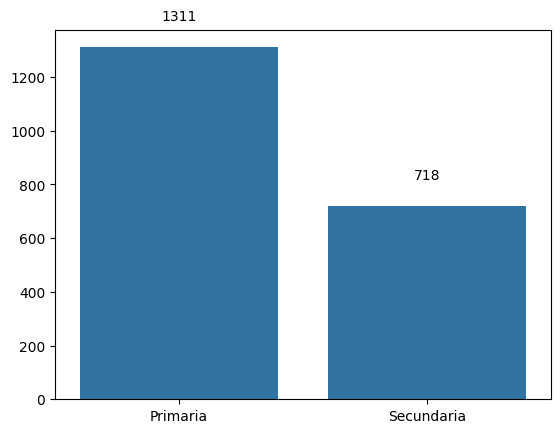

In [ ]:
sns.barplot(x=['Primaria', 'Secundaria'], y=[rows_quantity_primaria, rows_quantity_secundaria])
for i, v in enumerate([rows_quantity_primaria, rows_quantity_secundaria]):
    plt.text(i, v + 100, str(v), ha='center')
plt.show()

### Output

##### Concatenate both df

In [ ]:
#saving separately to csv files
df_primaria_arequipa.to_csv('../../data/cleaned/listado_escuelas_primaria_arequipa.csv', index=False)
df_secundaria_arequipa.to_csv('../../data/cleaned/listado_escuelas_secundaria_arequipa.csv', index=False)
#adding them together and saving to csv file
df_primaria_secundaria_arequipa = pd.concat([df_primaria_arequipa, df_secundaria_arequipa], ignore_index=True)
df_primaria_secundaria_arequipa.to_csv('../../data/cleaned/listado_escuelas_primaria_y_secundaria_arequipa.csv', index=False)